# Semi-synthetic pairwise-choice data from Boerstler et al.

**Goal:** estimate a latent preference signal from real data (plain Bradley-Terry),
then use response time as a noise modulator to generate semi-synthetic repeated
observations.  Longer RT → flatter choice curve → more label noise (Weber's law /
drift-diffusion intuition).

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from dataclasses import dataclass
from typing import Optional, Union

In [28]:
# ── Load and pre-process Boerstler data ───────────────────────────────────────
#
# Sign convention — re-sign every attribute so higher = better:
#   alco:     higher alcohol content → WORSE  → SIGN = -1
#   dep:      higher score           → BETTER → SIGN = +1
#   life:     higher life quality    → BETTER → SIGN = +1
#   criminal: higher crime rate      → WORSE  → SIGN = -1
#
# Choice encoding:
#   y = 1  →  left option (A) chosen
#   raw column 'chosen': 0 = left, 1 = right  →  y = (chosen == 0)

L_COLS = ['lalco', 'ldep', 'llife', 'lcrim']
R_COLS = ['ralco', 'rdep', 'rlife', 'rcrim']
SIGN   = np.array([-1.0, 1.0, 1.0, -1.0])
ATTRS  = ['alco', 'dep', 'life', 'crim']

df_raw = pd.read_csv('boerstler_data_labeled.csv', index_col=0)

# ── Restrict to person 0 ──────────────────────────────────────────────────────
PERSON_ID = 0
df_raw = df_raw[df_raw['person_id'] == PERSON_ID].reset_index(drop=True)

xA_all = (df_raw[L_COLS].values * SIGN).astype(float)   # (N, 4)  sign-corrected
xB_all = (df_raw[R_COLS].values * SIGN).astype(float)   # (N, 4)
y_all  = (df_raw['chosen'].values == 0).astype(float)   # y=1 → left chosen
rt_all = df_raw['secElasped'].values.astype(float)       # response times [sec]

N, K = xA_all.shape
print(f"Loaded {N:,} trials for person {PERSON_ID}, {K} features")
print(f"y = 1 (left chosen): {y_all.mean():.2%}")
print(f"RT  median={np.nanmedian(rt_all):.2f}s  mean={np.nanmean(rt_all):.2f}s  "
      f"min={np.nanmin(rt_all):.2f}s  max={np.nanmax(rt_all):.2f}s")

Loaded 600 trials for person 0, 4 features
y = 1 (left chosen): 50.50%
RT  median=8.00s  mean=13.98s  min=2.00s  max=174.00s


In [29]:
def build_pairwise_differences(xA: np.ndarray, xB: np.ndarray) -> np.ndarray:
    """
    Compute feature-difference vectors for the Bradley-Terry model.

    Parameters
    ----------
    xA : (N, K)  sign-corrected feature vectors for option A (left)
    xB : (N, K)  sign-corrected feature vectors for option B (right)

    Returns
    -------
    dx : (N, K)  dx[t] = xA[t] - xB[t]
         Positive entries favour A; negative entries favour B.
    """
    xA = np.asarray(xA, dtype=float)
    xB = np.asarray(xB, dtype=float)
    if xA.shape != xB.shape:
        raise ValueError(f"Shape mismatch: xA={xA.shape}, xB={xB.shape}")
    return xA - xB

In [30]:
@dataclass
class BTResult:
    """Results from a fitted plain Bradley-Terry model."""
    w_hat:    np.ndarray   # (K,)  MLE weights
    se:       np.ndarray   # (K,)  asymptotic standard errors
    gap:      np.ndarray   # (N,)  latent gaps: dx @ w_hat
    p_hat:    np.ndarray   # (N,)  fitted choice probabilities
    log_lik:  float
    aic:      float
    bic:      float
    n_obs:    int
    n_params: int
    opt:      object       # scipy OptimizeResult

    def summary(self, attr_labels=None):
        lbl = attr_labels or [f"w[{i}]" for i in range(len(self.w_hat))]
        print(f"Plain BT — N={self.n_obs:,}  log-lik={self.log_lik:.4f}  "
              f"AIC={self.aic:.2f}  BIC={self.bic:.2f}")
        print(f"  {'Attr':<10} {'weight':>10} {'SE':>10} {'z':>8}")
        print(f"  {'-'*10} {'-'*10} {'-'*10} {'-'*8}")
        for lb, w, se in zip(lbl, self.w_hat, self.se):
            z = w / se if se > 1e-14 else float('nan')
            print(f"  {lb:<10} {w:>10.4f} {se:>10.4f} {z:>8.2f}")


def fit_plain_bt(dx: np.ndarray, y: np.ndarray, *,
                 w_init: Optional[np.ndarray] = None,
                 maxiter: int = 2000) -> BTResult:
    """
    Fit a plain Bradley-Terry / logistic choice model by maximum likelihood.

    Model
    -----
        eta[t] = dx[t] @ w
        P(y[t]=1) = sigmoid(eta[t])

    NLL (numerically stable via logaddexp):
        NLL(w) = sum_t [ logaddexp(0, eta[t]) - y[t]*eta[t] ]

    Standard errors from inverse observed Fisher information:
        H = X^T diag(p*(1-p)) X   (PSD by construction)

    Parameters
    ----------
    dx      : (N, K) feature differences
    y       : (N,) binary choices — 1 if option A chosen, 0 otherwise
    w_init  : (K,) optional starting weights (default: zeros)
    maxiter : L-BFGS-B iteration limit

    Returns
    -------
    BTResult dataclass
    """
    dx = np.asarray(dx, dtype=float)
    y  = np.asarray(y,  dtype=float)
    N, K = dx.shape
    if y.shape != (N,):
        raise ValueError(f"y must have shape ({N},), got {y.shape}")
    if not np.all((y == 0) | (y == 1)):
        raise ValueError("y must be binary (0 or 1)")

    w0 = w_init.copy() if w_init is not None else np.zeros(K)

    def nll(w):
        eta = dx @ w
        return float(np.sum(np.logaddexp(0.0, eta) - y * eta))

    def fisher(w):
        """Observed Fisher information matrix — PSD by construction."""
        eta = np.clip(dx @ w, -500, 500)
        p   = 1.0 / (1.0 + np.exp(-eta))
        wts = p * (1.0 - p)
        return (dx * wts[:, None]).T @ dx   # (K, K)

    res = minimize(nll, w0, method='L-BFGS-B',
                   options={'maxiter': maxiter, 'ftol': 1e-12, 'gtol': 1e-8})

    w = res.x
    H = fisher(w)
    try:
        se = np.sqrt(np.maximum(0.0, np.diag(np.linalg.inv(H))))
    except np.linalg.LinAlgError:
        se = np.full(K, np.nan)

    gap = dx @ w
    p   = 1.0 / (1.0 + np.exp(-np.clip(gap, -500, 500)))
    ll  = -res.fun
    return BTResult(
        w_hat=w, se=se, gap=gap, p_hat=p,
        log_lik=ll,
        aic=-2.0*ll + 2.0*K,
        bic=-2.0*ll + K*np.log(N),
        n_obs=N, n_params=K, opt=res
    )

In [31]:
def compute_rt_sensitivity(rt: np.ndarray, *,
                            alpha: float = 0.0,
                            gamma: float = 0.5) -> tuple:
    """
    Compute RT-based sensitivity  lambda(rt) = exp(alpha - gamma * z_rt).

    The sensitivity lambda scales the latent gap before the sigmoid:
        p = sigmoid(lambda * gap)

    Larger RT → larger z_rt → smaller lambda → p closer to 0.5 → more noise.

    Parameters
    ----------
    rt    : (M,) positive response times
    alpha : float  baseline log-decisiveness  (default 0.0)
              At z_rt=0 (median RT), lambda = exp(alpha).
              alpha=0  → lambda=1 at median RT, so probabilities match the
                         raw BT gap directly — a natural, calibrated baseline.
              Increase alpha to amplify overall decisiveness.
    gamma : float  RT noise sensitivity  (default 0.5, must be >= 0)
              gamma=0   → RT has no effect on lambda.
              gamma=0.5 → one-SD increase in log-RT reduces lambda by ~39 pct.
              gamma=1.0 → one-SD increase in log-RT reduces lambda by ~63 pct.

    Returns
    -------
    log_rt    : (M,) natural log of RT
    z_rt      : (M,) standardised log-RT (mean 0, std 1 across this batch)
    lambda_rt : (M,) per-observation sensitivity values
    """
    rt = np.asarray(rt, dtype=float)
    if not np.all(rt > 0):
        raise ValueError("All response times must be strictly positive")
    if gamma < 0:
        raise ValueError(f"gamma must be >= 0, got {gamma}")

    log_rt = np.log(rt)
    mu     = log_rt.mean()
    sig    = log_rt.std(ddof=1)
    z_rt   = (log_rt - mu) / (sig if sig > 1e-12 else 1.0)
    lam    = np.exp(alpha - gamma * z_rt)
    return log_rt, z_rt, lam

In [32]:
def make_repeated_dataset(xA: np.ndarray,
                           xB: np.ndarray,
                           dx: np.ndarray,
                           gap: np.ndarray, *,
                           n_repeats: int = 4,
                           rt_observed: Optional[np.ndarray] = None,
                           rt_log_mean: float = 0.0,
                           rt_log_std:  float = 0.5,
                           rng: Optional[Union[int, np.random.Generator]] = None
                           ) -> pd.DataFrame:
    """
    Create n_repeats copies of each original query.

    Two RT modes
    ------------
    A. Observed RTs (rt_observed is not None):
       Pass an array of shape (N * n_repeats,) with one RT per repeated row.
       Use this when you have actual re-presentation RTs from your study.

    B. Simulated RTs (rt_observed is None):
       RTs are drawn i.i.d. from LogNormal(rt_log_mean, rt_log_std).
       Set rt_log_mean = np.log(rt).mean() and rt_log_std = np.log(rt).std()
       from your real RT data to match the empirical RT distribution.

    Parameters
    ----------
    xA, xB      : (N, K) sign-corrected feature arrays for options A and B
    dx          : (N, K) feature differences = xA - xB
    gap         : (N,) latent preference gaps from the fitted BT model (dx @ w_hat)
    n_repeats   : copies per original query (default 4)
    rt_observed : (N * n_repeats,) pre-specified RTs, one per repeated row (mode A)
    rt_log_mean : lognormal mu for simulated log-RTs (mode B)
    rt_log_std  : lognormal sigma for simulated log-RTs (mode B)
    rng         : int seed or numpy Generator for reproducibility

    Returns
    -------
    df_rep : DataFrame with columns:
        query_id, repeat_id, gap, rt, xA_0..xA_{K-1}, xB_0..xB_{K-1}, dx_0..dx_{K-1}
    """
    rng = np.random.default_rng(rng)
    xA  = np.asarray(xA,  dtype=float)
    xB  = np.asarray(xB,  dtype=float)
    dx  = np.asarray(dx,  dtype=float)
    gap = np.asarray(gap, dtype=float)

    N, K = xA.shape
    M    = N * n_repeats

    if xB.shape != (N, K) or dx.shape != (N, K) or gap.shape != (N,):
        raise ValueError("Shapes of xA, xB, dx, gap must be consistent: (N, K), (N, K), (N, K), (N,)")

    query_ids  = np.repeat(np.arange(N), n_repeats)    # 0,0,..,1,1,..,N-1
    repeat_ids = np.tile(np.arange(n_repeats), N)      # 0,1,..,n_repeats-1, 0,1,...

    xA_rep  = np.repeat(xA,  n_repeats, axis=0)        # (M, K)
    xB_rep  = np.repeat(xB,  n_repeats, axis=0)
    dx_rep  = np.repeat(dx,  n_repeats, axis=0)
    gap_rep = np.repeat(gap, n_repeats)                 # (M,)

    # ── Response times ────────────────────────────────────────────────────────
    if rt_observed is not None:
        rt_arr = np.asarray(rt_observed, dtype=float)
        if rt_arr.shape != (M,):
            raise ValueError(
                f"rt_observed must have shape ({M},) = N*n_repeats={N}*{n_repeats}, "
                f"got {rt_arr.shape}")
        rt = rt_arr
    else:
        rt = rng.lognormal(mean=rt_log_mean, sigma=rt_log_std, size=M)

    df_rep = pd.DataFrame({
        'query_id':  query_ids,
        'repeat_id': repeat_ids,
        'gap':       gap_rep,
        'rt':        rt,
    })
    for i in range(K):
        df_rep[f'xA_{i}'] = xA_rep[:, i]
        df_rep[f'xB_{i}'] = xB_rep[:, i]
        df_rep[f'dx_{i}'] = dx_rep[:, i]

    assert len(df_rep) == M
    return df_rep

In [33]:
def simulate_repeated_choices(df_rep: pd.DataFrame, *,
                               alpha: float = 0.0,
                               gamma: float = 0.5,
                               rng: Optional[Union[int, np.random.Generator]] = None
                               ) -> pd.DataFrame:
    """
    Add RT-modulated sensitivity and sample binary choices.

    Why this is a rigorous semi-synthetic procedure
    -----------------------------------------------
    1. Signal from data: gap[t] = dx[t] @ w_hat comes from a properly fitted
       BT model, capturing the real latent preference structure from observations.
    2. RT as noise only: response time modulates the *noise level*, not the
       signal itself.  This mirrors the empirical regularity that slower
       responses tend to be less consistent (drift-diffusion interpretation:
       slow responses → weak evidence → near-threshold accumulation → more
       variable outcomes).
    3. No arbitrary label flipping: noise arises via the sensitivity lambda
       that scales the gap before the sigmoid.  When lambda is small,
       p_rep -> 0.5 naturally, without any post-hoc label manipulation.
    4. Calibrated: when gamma=0 and alpha=0, lambda=1 everywhere, recovering
       plain BT predictions exactly.  gamma and alpha control *how much* RT
       matters, not *whether* preferences are real.

    Model equations
    ---------------
        log_rt    = log(rt)
        z_rt      = (log_rt - mean(log_rt)) / std(log_rt)   [standardised]
        lambda_rt = exp(alpha - gamma * z_rt)
        p_rep     = sigmoid(lambda_rt * gap)
        y_rep     ~ Bernoulli(p_rep)

    Parameters
    ----------
    df_rep : DataFrame from make_repeated_dataset (must contain 'gap', 'rt')
    alpha  : float  baseline log-decisiveness  (default 0.0)
    gamma  : float  RT noise sensitivity (default 0.5, must be >= 0)
    rng    : int seed or numpy Generator

    Returns
    -------
    df_out : copy of df_rep with added columns:
        log_rt, z_rt, lambda_rt, p_rep, y_rep
    """
    rng    = np.random.default_rng(rng)
    df_out = df_rep.copy()

    rt  = df_rep['rt'].values
    gap = df_rep['gap'].values

    log_rt, z_rt, lam = compute_rt_sensitivity(rt, alpha=alpha, gamma=gamma)
    eta   = lam * gap
    p_rep = 1.0 / (1.0 + np.exp(-np.clip(eta, -500, 500)))
    y_rep = rng.binomial(1, p_rep).astype(float)

    df_out['log_rt']    = log_rt
    df_out['z_rt']      = z_rt
    df_out['lambda_rt'] = lam
    df_out['p_rep']     = p_rep
    df_out['y_rep']     = y_rep

    return df_out

In [34]:
# ── Pipeline parameters ────────────────────────────────────────────────────────
SEED      = 42
N_REPEATS = 10    # copies per original query
ALPHA     = 0.0   # baseline log-decisiveness: lambda=exp(0)=1 at median RT
GAMMA     = 0.5   # RT sensitivity: 1-SD increase in log-RT reduces lambda by ~39%

# ── Step 1+2: Fit plain BT on full dataset; compute latent gaps ───────────────
dx_all = build_pairwise_differences(xA_all, xB_all)
bt     = fit_plain_bt(dx_all, y_all)
bt.summary(attr_labels=ATTRS)

print(f"\nLatent gap statistics (dx @ w_hat):")
print(f"  mean   = {bt.gap.mean():+.4f}")
print(f"  std    = {bt.gap.std():.4f}")
print(f"  range  = [{bt.gap.min():.4f}, {bt.gap.max():.4f}]")
print(f"  |gap|>1: {(np.abs(bt.gap)>1).mean():.1%}  (strong preference)")

# ── Step 3: Create repeated dataset ───────────────────────────────────────────
# Parameterise lognormal to match the empirical RT distribution.
rt_valid   = rt_all[np.isfinite(rt_all) & (rt_all > 0)]
rt_log_mu  = np.log(rt_valid).mean()
rt_log_sig = np.log(rt_valid).std(ddof=1)
print(f"\nEmpirical RT: log-RT mu={rt_log_mu:.3f}, sigma={rt_log_sig:.3f}")
print(f"  (simulated RTs will be drawn from this lognormal)")

df_rep = make_repeated_dataset(
    xA_all, xB_all, dx_all, bt.gap,
    n_repeats  = N_REPEATS,
    rt_log_mean= rt_log_mu,
    rt_log_std = rt_log_sig,
    rng        = SEED
)

# ── Steps 4+5: Generate semi-synthetic choices ─────────────────────────────────
df_semi = simulate_repeated_choices(df_rep, alpha=ALPHA, gamma=GAMMA, rng=SEED)

print(f"\nSemi-synthetic dataset: {len(df_semi):,} rows  "
      f"({N:,} queries x {N_REPEATS} repeats)")
print(f"  y_rep mean = {df_semi['y_rep'].mean():.3f}   "
      f"(original y mean = {y_all.mean():.3f})")
print(f"  p_rep mean = {df_semi['p_rep'].mean():.3f}   "
      f"std = {df_semi['p_rep'].std():.3f}")
print(f"  lambda_rt  mean={df_semi['lambda_rt'].mean():.3f}  "
      f"std={df_semi['lambda_rt'].std():.3f}  "
      f"range=[{df_semi['lambda_rt'].min():.3f}, {df_semi['lambda_rt'].max():.3f}]")
df_semi.head(8)

Plain BT — N=600  log-lik=-121.8909  AIC=251.78  BIC=269.37
  Attr           weight         SE        z
  ---------- ---------- ---------- --------
  alco           0.4478     0.0856     5.23
  dep            3.4835     0.3432    10.15
  life           1.1999     0.1813     6.62
  crim           2.2205     0.2400     9.25

Latent gap statistics (dx @ w_hat):
  mean   = -0.2419
  std    = 6.9630
  range  = [-17.9991, 17.9991]
  |gap|>1: 87.8%  (strong preference)

Empirical RT: log-RT mu=2.295, sigma=0.713
  (simulated RTs will be drawn from this lognormal)

Semi-synthetic dataset: 6,000 rows  (600 queries x 10 repeats)
  y_rep mean = 0.497   (original y mean = 0.505)
  p_rep mean = 0.492   std = 0.427
  lambda_rt  mean=1.134  std=0.612  range=[0.178, 8.878]


,query_id,repeat_id,gap,rt,xA_0,xB_0,dx_0,xA_1,xB_1,dx_1,...,xB_2,dx_2,xA_3,xB_3,dx_3,log_rt,z_rt,lambda_rt,p_rep,y_rep
0,0,0,-1.324911,12.335379,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,2.512471,0.312119,0.855508,0.243521,1.0
1,0,1,-1.324911,4.730722,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,1.554078,-1.028409,1.672308,0.098353,0.0
2,0,2,-1.324911,16.948078,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,2.830154,0.756470,0.685069,0.287480,1.0
3,0,3,-1.324911,19.407350,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,2.965652,0.945994,0.623132,0.304577,1.0
4,0,4,-1.324911,2.471326,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,0.904755,-1.936633,2.633508,0.029622,0.0
5,0,5,-1.324911,3.924372,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,1.367206,-1.289791,1.905788,0.074124,1.0
6,0,6,-1.324911,10.874365,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,2.386408,0.135792,0.934358,0.224795,0.0
7,0,7,-1.324911,7.924046,-2.0,-4.0,2.0,2.0,2.0,0.0,...,1.0,0.0,-1.0,-0.0,-1.0,2.069902,-0.306913,1.165857,0.175859,0.0


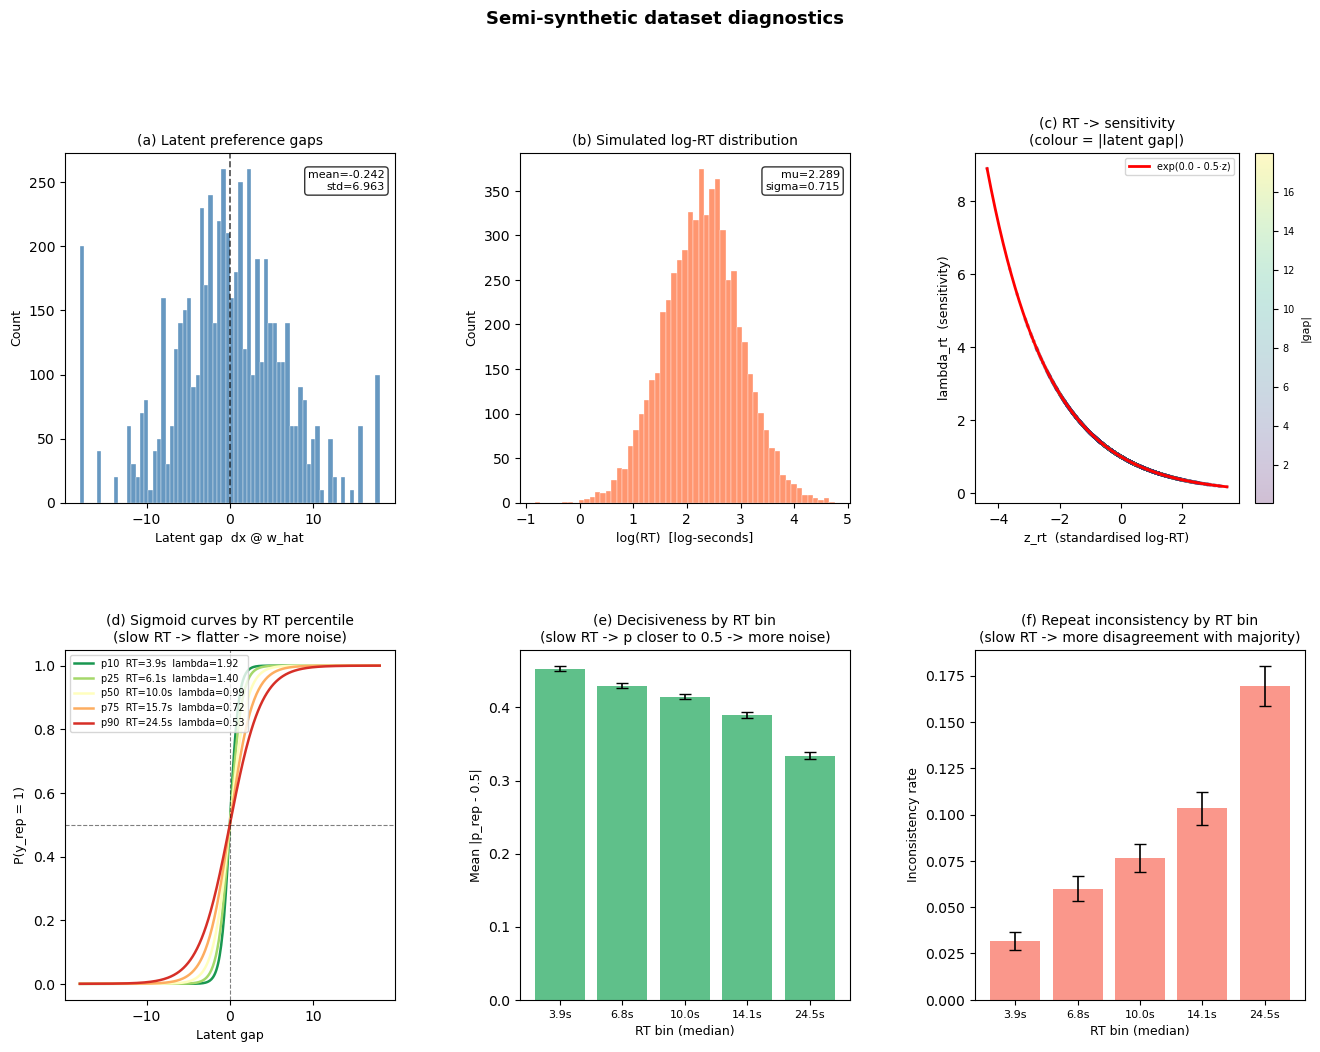

Saved: semi_synthetic_diagnostics.png


In [35]:
def plot_diagnostics(bt_result: BTResult,
                     df_semi:   pd.DataFrame, *,
                     alpha:      float = 0.0,
                     gamma:      float = 0.5,
                     attr_labels = None,
                     n_rt_bins:  int   = 5,
                     figsize:    tuple = (16, 11)) -> None:
    """
    Six-panel diagnostic figure.

    (a) Histogram of latent gaps
    (b) Histogram of simulated log-RT
    (c) Scatter: z_rt vs lambda_rt  (colour = |gap|)
    (d) Sigmoid curves at RT percentiles (slow RT -> flatter curve)
    (e) Mean |p_rep - 0.5| by RT bin  (slow RT -> closer to 0.5 -> more noise)
    (f) Repeat inconsistency rate by RT bin
    """
    gap   = df_semi['gap'].values
    z_rt  = df_semi['z_rt'].values
    lam   = df_semi['lambda_rt'].values
    p_rep = df_semi['p_rep'].values
    rt    = df_semi['rt'].values
    log_rt = df_semi['log_rt'].values

    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)
    axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]

    # ── (a) Latent gap histogram ─────────────────────────────────────────────
    ax = axes[0]
    ax.hist(gap, bins=70, color='steelblue', alpha=0.82, edgecolor='white', lw=0.3)
    ax.axvline(0, color='k', lw=1.2, ls='--', alpha=0.7)
    ax.set_xlabel('Latent gap  dx @ w_hat', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title('(a) Latent preference gaps', fontsize=10)
    ax.text(0.97, 0.95,
            f"mean={gap.mean():+.3f}\nstd={gap.std():.3f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # ── (b) Log-RT histogram ─────────────────────────────────────────────────
    ax = axes[1]
    ax.hist(log_rt, bins=55, color='coral', alpha=0.82, edgecolor='white', lw=0.3)
    ax.set_xlabel('log(RT)  [log-seconds]', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title('(b) Simulated log-RT distribution', fontsize=10)
    ax.text(0.97, 0.95,
            f"mu={log_rt.mean():.3f}\nsigma={log_rt.std():.3f}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # ── (c) z_rt vs lambda_rt ────────────────────────────────────────────────
    ax = axes[2]
    sc = ax.scatter(z_rt, lam, c=np.abs(gap), cmap='viridis',
                    alpha=0.25, s=3, rasterized=True)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('|gap|', fontsize=8)
    cb.ax.tick_params(labelsize=7)
    z_grid = np.linspace(z_rt.min(), z_rt.max(), 300)
    ax.plot(z_grid, np.exp(alpha - gamma * z_grid), 'r-', lw=2,
            label=f'exp({alpha:.1f} - {gamma:.1f}·z)')
    ax.set_xlabel('z_rt  (standardised log-RT)', fontsize=9)
    ax.set_ylabel('lambda_rt  (sensitivity)', fontsize=9)
    ax.set_title('(c) RT -> sensitivity\n(colour = |latent gap|)', fontsize=10)
    ax.legend(fontsize=7)

    # ── (d) Sigmoid curves at RT percentiles ─────────────────────────────────
    ax = axes[3]
    gap_grid = np.linspace(gap.min(), gap.max(), 400)
    pcts     = [10, 25, 50, 75, 90]
    rt_pctls = np.percentile(rt, pcts)
    mu_l     = log_rt.mean()
    sig_l    = log_rt.std(ddof=1)
    cmap     = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(pcts)))
    for pct, rv, col in zip(pcts, rt_pctls, cmap):
        z_val   = (np.log(rv) - mu_l) / (sig_l if sig_l > 1e-12 else 1.0)
        lam_val = np.exp(alpha - gamma * z_val)
        p_curve = 1.0 / (1.0 + np.exp(-lam_val * gap_grid))
        ax.plot(gap_grid, p_curve, color=col, lw=1.8,
                label=f'p{pct}  RT={rv:.1f}s  lambda={lam_val:.2f}')
    ax.axhline(0.5, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.axvline(0.0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Latent gap', fontsize=9)
    ax.set_ylabel('P(y_rep = 1)', fontsize=9)
    ax.set_title('(d) Sigmoid curves by RT percentile\n'
                 '(slow RT -> flatter -> more noise)', fontsize=10)
    ax.legend(fontsize=7, loc='upper left')

    # ── (e) Mean |p_rep - 0.5| by RT bin ─────────────────────────────────────
    ax = axes[4]
    df_tmp = pd.DataFrame({'rt': rt, 'dec': np.abs(p_rep - 0.5)})
    df_tmp['bin'] = pd.qcut(rt, q=n_rt_bins, labels=False)
    grp = (df_tmp.groupby('bin', observed=True)
               .agg(rt_med=('rt', 'median'),
                    dec_mean=('dec', 'mean'),
                    dec_sem=('dec', lambda x: x.std(ddof=1) / len(x)**0.5))
               .reset_index())
    ax.bar(range(n_rt_bins), grp['dec_mean'], color='mediumseagreen', alpha=0.82,
           yerr=grp['dec_sem'], capsize=4, error_kw={'lw': 1.2})
    ax.set_xticks(range(n_rt_bins))
    ax.set_xticklabels([f'{v:.1f}s' for v in grp['rt_med']], fontsize=8)
    ax.set_xlabel('RT bin (median)', fontsize=9)
    ax.set_ylabel('Mean |p_rep - 0.5|', fontsize=9)
    ax.set_title('(e) Decisiveness by RT bin\n'
                 '(slow RT -> p closer to 0.5 -> more noise)', fontsize=10)

    # ── (f) Repeat inconsistency by RT bin ────────────────────────────────────
    ax = axes[5]
    # Inconsistency: does y_rep disagree with the majority vote within each query?
    df_maj = (df_semi.groupby('query_id')['y_rep']
                     .transform(lambda x: (x.mean() >= 0.5).astype(float)))
    df_inc = df_semi.copy()
    df_inc['majority']     = df_maj
    df_inc['inconsistent'] = (df_inc['y_rep'] != df_inc['majority']).astype(float)
    df_inc['bin']          = pd.qcut(df_inc['rt'], q=n_rt_bins, labels=False)
    grp2 = (df_inc.groupby('bin', observed=True)
                  .agg(rt_med=('rt', 'median'),
                       inc_rate=('inconsistent', 'mean'),
                       inc_sem=('inconsistent', lambda x: x.std(ddof=1) / len(x)**0.5))
                  .reset_index())
    ax.bar(range(n_rt_bins), grp2['inc_rate'], color='salmon', alpha=0.82,
           yerr=grp2['inc_sem'], capsize=4, error_kw={'lw': 1.2})
    ax.set_xticks(range(n_rt_bins))
    ax.set_xticklabels([f'{v:.1f}s' for v in grp2['rt_med']], fontsize=8)
    ax.set_xlabel('RT bin (median)', fontsize=9)
    ax.set_ylabel('Inconsistency rate', fontsize=9)
    ax.set_title('(f) Repeat inconsistency by RT bin\n'
                 '(slow RT -> more disagreement with majority)', fontsize=10)

    fig.suptitle('Semi-synthetic dataset diagnostics', fontsize=13,
                 fontweight='bold', y=1.01)
    plt.savefig('semi_synthetic_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: semi_synthetic_diagnostics.png")


plot_diagnostics(bt, df_semi, alpha=ALPHA, gamma=GAMMA, attr_labels=ATTRS, n_rt_bins=5)

In [36]:
# ── Refit plain BT and widening BT on the semi-synthetic data ─────────────────
#
# We extract dx, y_rep, and the scale proxy s from df_semi, then fit:
#   1. Plain BT          : P(y=1) = sigmoid(dx @ w)
#   2. Widening BT       : P(y=1) = sigmoid(exp(beta*s) * (dx @ w)),  beta <= 0
#
# Both weight vectors are then projected onto the probability simplex:
#   omega = clip(w, 0) / sum(clip(w, 0))
# so we can compare *relative* feature importance on a common scale.

from scipy.stats import chi2 as _chi2

# ── Extract arrays from df_semi ───────────────────────────────────────────────
dx_cols = [f'dx_{i}' for i in range(K)]
xA_cols = [f'xA_{i}' for i in range(K)]
xB_cols = [f'xB_{i}' for i in range(K)]

dx_semi = df_semi[dx_cols].values.astype(float)          # (M, K)
y_semi  = df_semi['y_rep'].values.astype(float)          # (M,)
xA_semi = df_semi[xA_cols].values.astype(float)          # (M, K)
xB_semi = df_semi[xB_cols].values.astype(float)          # (M, K)
s_semi  = (np.linalg.norm(xA_semi, axis=1)
           + np.linalg.norm(xB_semi, axis=1))            # (M,)  scale proxy

M = len(y_semi)
print(f"Semi-synthetic dataset: M={M:,} rows, K={K} features")
print(f"s_semi: median={np.median(s_semi):.2f}  range=[{s_semi.min():.2f}, {s_semi.max():.2f}]")


# ── Simplex projection ────────────────────────────────────────────────────────
def simplex_project(w: np.ndarray) -> np.ndarray:
    """
    Project w onto the probability simplex.

    Clips negative weights to zero, then normalises to sum=1.
    Falls back to uniform weights if all entries are <= 0.
    """
    w_pos = np.maximum(w, 0.0)
    total = w_pos.sum()
    return w_pos / total if total > 1e-14 else np.ones(len(w)) / len(w)


# ── Widening BT implementation ────────────────────────────────────────────────
# (Self-contained here so this notebook is independent of bt_data_prep.ipynb)

@dataclass
class WideningBTResult:
    w_hat:    np.ndarray   # (K,) feature weights
    beta_hat: float        # scale-sensitivity (beta <= 0)
    p_hat:    np.ndarray   # (M,) fitted choice probabilities
    log_lik:  float
    aic:      float
    bic:      float
    n_obs:    int
    n_params: int
    opt:      object

    def summary(self, attr_labels=None):
        lbl = attr_labels or [f'w[{i}]' for i in range(len(self.w_hat))]
        print(f"Widening BT — N={self.n_obs:,}  beta={self.beta_hat:+.6f}  "
              f"log-lik={self.log_lik:.4f}  AIC={self.aic:.2f}")
        print(f"  {'Attr':<10} {'weight':>10}")
        for lb, w in zip(lbl, self.w_hat):
            print(f"  {lb:<10} {w:>10.4f}")


def _nll_widening(params, dx, y, s):
    """NLL for widening BT with params = [w..., beta]."""
    w, beta = params[:-1], params[-1]
    eta = np.exp(beta * s) * (dx @ w)
    return float(np.sum(np.logaddexp(0.0, eta) - y * eta))


def _fit_widening_one(w0, beta0, dx, y, s, maxiter):
    """Single optimisation run from a given starting point."""
    p0     = np.append(w0, beta0)
    K_     = dx.shape[1]
    bounds = [(-np.inf, np.inf)] * K_ + [(-np.inf, 0.0)]   # beta <= 0
    return minimize(_nll_widening, p0, args=(dx, y, s), method='L-BFGS-B',
                    bounds=bounds,
                    options={'maxiter': maxiter, 'ftol': 1e-12, 'gtol': 1e-8})


def fit_widening_bt(dx, y, s, *,
                    bt_fit=None,
                    n_restarts: int = 8,
                    w_noise:    float = 0.5,
                    beta_noise: float = 0.05,
                    maxiter:    int   = 2000,
                    rng=None,
                    verbose:    bool  = False) -> WideningBTResult:
    """
    Fit a widening Bradley-Terry model by MLE with multiple random restarts.

    Model:
        eta[t] = exp(beta * s[t]) * (dx[t] @ w),   beta <= 0
        P(y[t]=1) = sigmoid(eta[t])

    The canonical starting point is (w_bt, beta=0), which recovers the plain
    BT solution — a valid saddle point of the bilinear NLL surface.
    Additional restarts perturb from there to escape local optima.

    Parameters
    ----------
    dx         : (N, K) feature differences
    y          : (N,) binary choices
    s          : (N,) scale proxy  ||xA||_2 + ||xB||_2
    bt_fit     : BTResult  used for warm-start (optional)
    n_restarts : total number of optimisation runs (default 8)
    w_noise    : Gaussian noise scale for weight perturbations
    beta_noise : Gaussian noise scale for beta perturbations
    verbose    : print per-restart details
    """
    rng = np.random.default_rng(rng)
    K_  = dx.shape[1]
    w_bt = bt_fit.w_hat if bt_fit is not None else np.zeros(K_)
    ll_bt = bt_fit.log_lik if bt_fit is not None else 0.0

    # Canonical warm-start: BT weights, beta=0
    best = _fit_widening_one(w_bt, 0.0, dx, y, s, maxiter)
    if verbose:
        print(f"  restart 0 (canonical): NLL={best.fun:.6f}")

    for i in range(n_restarts - 1):
        w0    = w_bt + rng.normal(0, w_noise, K_)
        b0    = min(0.0, rng.normal(0, beta_noise))
        trial = _fit_widening_one(w0, b0, dx, y, s, maxiter)
        if verbose:
            print(f"  restart {i+1}: NLL={trial.fun:.6f}  "
                  f"beta={trial.x[-1]:+.6f}")
        if trial.fun < best.fun:
            best = trial

    params = best.x
    w, beta = params[:-1], float(params[-1])
    eta = np.exp(beta * s) * (dx @ w)
    p   = 1.0 / (1.0 + np.exp(-np.clip(eta, -500, 500)))
    ll  = -best.fun
    n, k = len(y), K_ + 1

    # Likelihood-ratio test vs plain BT
    ll_diff = max(0.0, ll - ll_bt)
    pval    = _chi2.sf(2.0 * ll_diff, df=1)
    if verbose:
        print(f"  LR test vs plain BT: chi2={2*ll_diff:.4f}  p={pval:.4f}")

    return WideningBTResult(
        w_hat=w, beta_hat=beta, p_hat=p,
        log_lik=ll,
        aic=-2.0*ll + 2.0*k,
        bic=-2.0*ll + k*np.log(n),
        n_obs=n, n_params=k, opt=best
    )


# ── Fit both models ───────────────────────────────────────────────────────────
print("\nFitting plain BT on semi-synthetic data...")
bt_semi = fit_plain_bt(dx_semi, y_semi)

print("Fitting widening BT on semi-synthetic data (8 restarts)...")
wide_semi = fit_widening_bt(dx_semi, y_semi, s_semi,
                             bt_fit=bt_semi, n_restarts=8, rng=42, verbose=True)

# ── Simplex projections (omega) ───────────────────────────────────────────────
omega_bt   = simplex_project(bt_semi.w_hat)
omega_wide = simplex_project(wide_semi.w_hat)

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print("=" * 62)
print(f"{'Attribute':<10}  {'w (BT)':>9}  {'omega_BT':>9}  "
      f"{'w (Wide)':>9}  {'omega_Wide':>10}")
print("-" * 62)
for i, attr in enumerate(ATTRS):
    print(f"{attr:<10}  {bt_semi.w_hat[i]:>+9.4f}  {omega_bt[i]:>9.4f}  "
          f"{wide_semi.w_hat[i]:>+9.4f}  {omega_wide[i]:>10.4f}")
print("-" * 62)
print(f"{'sum':>10}  {'':>9}  {omega_bt.sum():>9.4f}  "
      f"{'':>9}  {omega_wide.sum():>10.4f}  (should be 1.0)")

print()
print(f"beta_hat (widening)  : {wide_semi.beta_hat:+.6f}")
print(f"  B(s) at s=median   : exp(beta*s_med) = {np.exp(wide_semi.beta_hat*np.median(s_semi)):.4f}")
print()
print(f"Plain BT    — log-lik={bt_semi.log_lik:.2f}  AIC={bt_semi.aic:.2f}")
print(f"Widening BT — log-lik={wide_semi.log_lik:.2f}  AIC={wide_semi.aic:.2f}")
delta_ll = wide_semi.log_lik - bt_semi.log_lik
print(f"  Delta log-lik = {delta_ll:+.4f}  "
      f"(LR test chi2={2*max(0,delta_ll):.4f}  "
      f"p={_chi2.sf(2*max(0,delta_ll), df=1):.4f})")

Semi-synthetic dataset: M=6,000 rows, K=4 features
s_semi: median=7.44  range=[2.41, 10.94]

Fitting plain BT on semi-synthetic data...
Fitting widening BT on semi-synthetic data (8 restarts)...
  restart 0 (canonical): NLL=1431.606897
  restart 1: NLL=1431.606897  beta=-0.015090
  restart 2: NLL=1431.606897  beta=-0.015090
  restart 3: NLL=1431.606897  beta=-0.015090
  restart 4: NLL=1431.606897  beta=-0.015090
  restart 5: NLL=1431.606897  beta=-0.015090
  restart 6: NLL=1431.606897  beta=-0.015090
  restart 7: NLL=1431.606897  beta=-0.015090
  LR test vs plain BT: chi2=0.6496  p=0.4202

Attribute      w (BT)   omega_BT   w (Wide)  omega_Wide
--------------------------------------------------------------
alco          +0.3815     0.0622    +0.4257      0.0622
dep           +2.8671     0.4672    +3.1974      0.4673
life          +1.0322     0.1682    +1.1523      0.1684
crim          +1.8559     0.3024    +2.0673      0.3021
------------------------------------------------------------

Queries: 600  (10 repeats each)
  exact ties (5/10)              : 8  (1.3%)
  decisive (0-2 or 8-10/10)        : 519  (86.5%)
Mean |kappa| on tied     : 0.0394
Mean |kappa| on decisive : 0.3702


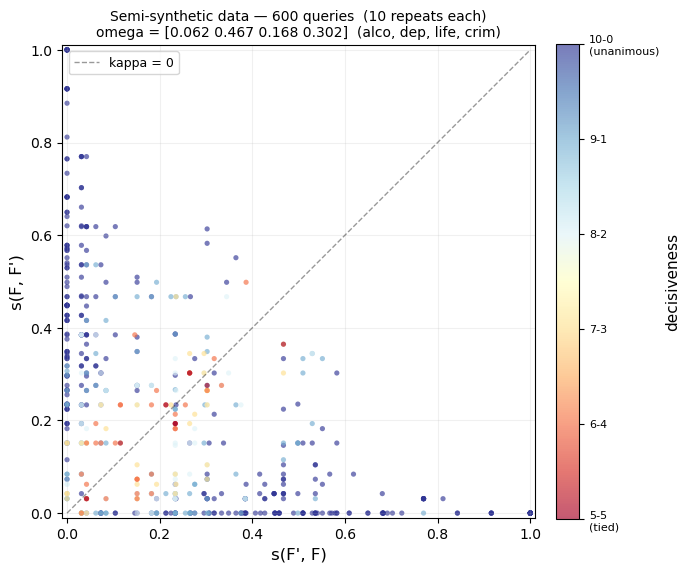

Saved: semi_synthetic_sxsy.png


In [37]:
# ── (sx, sy) scatter coloured by decisiveness ────────────────────────────────
#
# decisiveness = |left_count/nr - 0.5| * 2   in [0, 1]
#   0 = exact 5-5 tie (red)    → low signal, noise dominates
#   1 = unanimous 10-0 or 0-10 (blue) → strong signal
#
# Sorting: plot blue (decisive) first, red (tied) last so red sits on top.

# ── Aggregate to one row per original query ────────────────────────────────────
agg_dict = {f'dx_{i}': (f'dx_{i}', 'first') for i in range(K)}
agg_dict['left_count'] = ('y_rep', lambda x: int((x == 1).sum()))
agg_dict['n_reps']     = ('y_rep', 'count')

query_df = (df_semi
            .groupby('query_id', sort=True)
            .agg(**agg_dict)
            .reset_index())

dx_q    = query_df[[f'dx_{i}' for i in range(K)]].values.astype(float)
RAW_MAX = np.abs(dx_q).max(axis=0)      # per-feature max absolute diff
dx_q_n  = dx_q / RAW_MAX                # normalise to [-1, 1] per feature
d_q_n   = np.abs(dx_q_n)               # absolute diffs in [0, 1]

r_q  = d_q_n  @ omega_bt   # decisiveness (intensity) in [0, 1]
k_q  = dx_q_n @ omega_bt   # signed kappa in [-1, 1]
sx_q = (r_q - k_q) / 2     # s(F', F)
sy_q = (r_q + k_q) / 2     # s(F, F')

left_count   = query_df['left_count'].values.astype(int)
nr           = query_df['n_reps'].values[0]

# 0 = 5/10 tie (red), 1 = unanimous 0 or 10/10 (blue)
decisiveness = np.abs(left_count / nr - 0.5) * 2

split    = left_count == nr // 2
maj_left = left_count >  nr // 2
maj_rgt  = left_count <  nr // 2
decisive = (left_count <= 2) | (left_count >= nr - 2)

print(f"Queries: {len(query_df):,}  ({nr} repeats each)")
print(f"  exact ties ({nr//2}/{nr})              : {split.sum():,}  ({split.mean():.1%})")
print(f"  decisive (0-2 or 8-10/{nr})        : {decisive.sum():,}  ({decisive.mean():.1%})")
print(f"Mean |kappa| on tied     : {np.abs(k_q[split]).mean():.4f}")
print(f"Mean |kappa| on decisive : {np.abs(k_q[decisive]).mean():.4f}")

# Plot decisive (blue) first, tied (red) last → red on top
order  = np.argsort(decisiveness)[::-1]
sx_o   = sx_q[order]; sy_o = sy_q[order]; dec_o = decisiveness[order]

fig, ax = plt.subplots(figsize=(7, 6.5))
sc = ax.scatter(sx_o, sy_o, c=dec_o, cmap='RdYlBu',
                vmin=0, vmax=1, s=14, alpha=0.65, linewidths=0)

cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cb.set_label('decisiveness', fontsize=11)
cb.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cb.set_ticklabels([f'5-5\n(tied)', '6-4', '7-3', '8-2', '9-1', f'10-0\n(unanimous)'])
cb.ax.tick_params(labelsize=8)

ax.plot([0, 1], [0, 1], color='k', ls='--', lw=1.0, alpha=0.4, label='kappa = 0')
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01); ax.set_aspect('equal')
ax.set_xlabel("s(F', F)", fontsize=12); ax.set_ylabel("s(F, F')", fontsize=12)
ax.set_title(
    f'Semi-synthetic data — {len(query_df):,} queries  ({nr} repeats each)\n'
    f'omega = {np.round(omega_bt, 3)}  (alco, dep, life, crim)',
    fontsize=10)
ax.grid(True, alpha=0.18); ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('semi_synthetic_sxsy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: semi_synthetic_sxsy.png')

Group                         N   r  mean   r  med   r  std   |sx-sy| mean  sx-sy std
----------------------------------------------------------------------------------------
tied (5/10)                   8    0.4522   0.4369   0.2100         0.0394     0.0443
near-tie (4-6/10)            43    0.3661   0.4159   0.2028         0.0631     0.0777
decisive (0-2 or 8-10)      519    0.4742   0.4487   0.2436         0.3702     0.4500
maj-left (>5/10)            292    0.4502   0.4269   0.2323         0.3266     0.2516
maj-right (<5/10)           300    0.4669   0.4487   0.2529         0.3424     0.2756


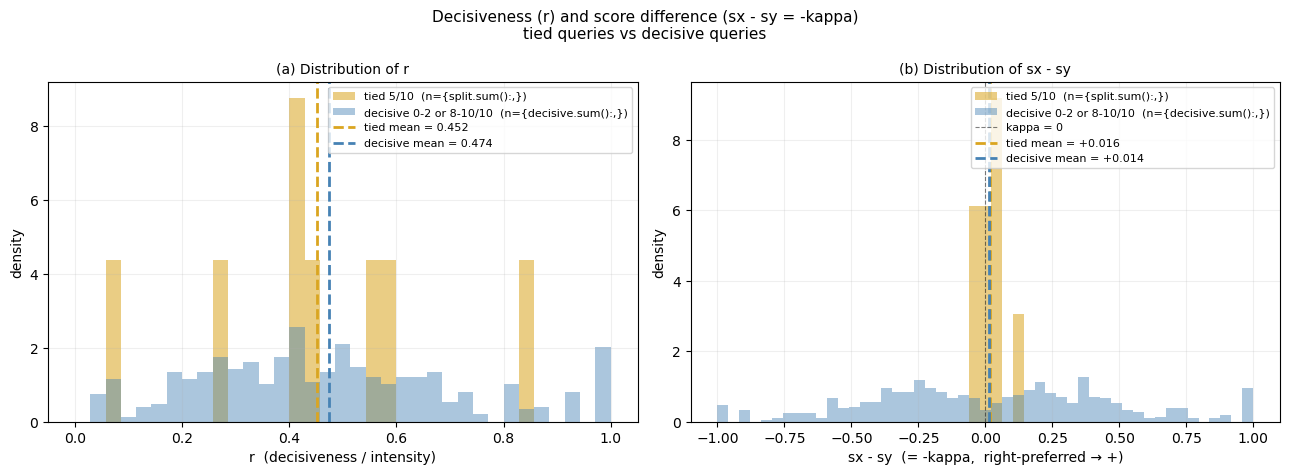

Saved: semi_synthetic_intensity_dist.png

KS test on r:         stat=0.2086   p=8.18e-01
Mann-Whitney on r:    stat=2048  p=9.50e-01
KS test on |sx-sy|:   stat=0.8786   p=1.52e-07
(small p -> tied and decisive queries have different distributions)


In [38]:
# ── Intensity and score-difference distributions: tied vs decisive queries ─────
#
# r      = d_norm @ omega  — decisiveness / intensity (in [0, 1])
# sx - sy = (r - k)/2 - (r + k)/2 = -k = -kappa
#           positive → right option preferred, negative → left option preferred
#           tied queries should cluster near 0; decisive queries should be spread

decisive = (left_count <= 2) | (left_count >= nr - 2)  # 8+/10 or 0-2/10 agreed

groups = {
    f'tied (5/{nr})'          : split,
    f'near-tie (4-6/{nr})'    : np.abs(left_count - nr//2) <= 1,
    f'decisive (0-2 or 8-10)' : decisive,
    f'maj-left (>{nr//2}/{nr})'    : maj_left,
    f'maj-right (<{nr//2}/{nr})'   : maj_rgt,
}

print(f"{'Group':<24} {'N':>6}  {'r  mean':>8} {'r  med':>8} {'r  std':>8}  "
      f"{'|sx-sy| mean':>13} {'sx-sy std':>10}")
print("-" * 88)
for lbl, mask in groups.items():
    r_sub   = r_q[mask]
    diff_sub= sx_q[mask] - sy_q[mask]     # = -kappa_normalised
    print(f"{lbl:<24} {mask.sum():>6}  "
          f"{r_sub.mean():>8.4f} {np.median(r_sub):>8.4f} {r_sub.std():>8.4f}  "
          f"{np.abs(diff_sub).mean():>13.4f} {diff_sub.std():>10.4f}")

# ── Overlapping distribution plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('Decisiveness (r) and score difference (sx - sy = -kappa)\n'
             'tied queries vs decisive queries', fontsize=11)

bins_r    = np.linspace(0, 1, 36)
bins_diff = np.linspace(-1, 1, 50)

style = {
    f'tied ({nr//2}/{nr})':      dict(color='goldenrod', alpha=0.55, label=f'tied {nr//2}/{nr}  (n={{split.sum():,}})'),
    f'decisive (0-2,8-10)': dict(color='steelblue', alpha=0.45, label=f'decisive 0-2 or 8-10/{nr}  (n={{decisive.sum():,}})'),
}

# ── Left: r (decisiveness) ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(r_q[split],    bins=bins_r, density=True, **style[f'tied ({nr//2}/{nr})'])
ax.hist(r_q[decisive], bins=bins_r, density=True, **style[f'decisive (0-2,8-10)'])
ax.axvline(r_q[split].mean(),    color='goldenrod', lw=2, ls='--',
           label=f'tied mean = {r_q[split].mean():.3f}')
ax.axvline(r_q[decisive].mean(), color='steelblue',  lw=2, ls='--',
           label=f'decisive mean = {r_q[decisive].mean():.3f}')
ax.set_xlabel('r  (decisiveness / intensity)', fontsize=10)
ax.set_ylabel('density', fontsize=10)
ax.set_title('(a) Distribution of r', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# ── Right: sx - sy = -kappa ───────────────────────────────────────────────────
ax = axes[1]
diff_tied = sx_q[split]    - sy_q[split]
diff_dec  = sx_q[decisive] - sy_q[decisive]
ax.hist(diff_tied, bins=bins_diff, density=True, **style[f'tied ({nr//2}/{nr})'])
ax.hist(diff_dec,  bins=bins_diff, density=True, **style[f'decisive (0-2,8-10)'])
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.5, label='kappa = 0')
ax.axvline(diff_tied.mean(), color='goldenrod', lw=2, ls='--',
           label=f'tied mean = {diff_tied.mean():+.3f}')
ax.axvline(diff_dec.mean(),  color='steelblue',  lw=2, ls='--',
           label=f'decisive mean = {diff_dec.mean():+.3f}')
ax.set_xlabel('sx - sy  (= -kappa,  right-preferred → +)', fontsize=10)
ax.set_ylabel('density', fontsize=10)
ax.set_title('(b) Distribution of sx - sy', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('semi_synthetic_intensity_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: semi_synthetic_intensity_dist.png')

# ── Quick KS test: are the r distributions different? ─────────────────────────
from scipy.stats import ks_2samp, mannwhitneyu
ks_r   = ks_2samp(r_q[split], r_q[decisive])
mw_r   = mannwhitneyu(r_q[split], r_q[decisive], alternative='two-sided')
ks_d   = ks_2samp(np.abs(diff_tied), np.abs(diff_dec))
print(f"\nKS test on r:         stat={ks_r.statistic:.4f}   p={ks_r.pvalue:.2e}")
print(f"Mann-Whitney on r:    stat={mw_r.statistic:.0f}  p={mw_r.pvalue:.2e}")
print(f"KS test on |sx-sy|:   stat={ks_d.statistic:.4f}   p={ks_d.pvalue:.2e}")
print("(small p -> tied and decisive queries have different distributions)")

In [39]:
# ── Example: how to swap in your own arrays ───────────────────────────────────
#
# Suppose you have:
#   my_xA     : (N, K) sign-corrected feature arrays for option A
#   my_xB     : (N, K) sign-corrected feature arrays for option B
#   my_y      : (N,) binary choices
#   my_rt_rep : (N * 4,) actual response times for each repeated observation
#               (leave as None to simulate from lognormal)
#
# Then:

# 1. Compute feature differences
# dx = build_pairwise_differences(my_xA, my_xB)

# 2. Fit BT on your real data
# bt = fit_plain_bt(dx, my_y)
# bt.summary()

# 3. Build repeated dataset
#    Mode A — actual RTs for each repeat:
# df_rep = make_repeated_dataset(my_xA, my_xB, dx, bt.gap,
#                                n_repeats=4, rt_observed=my_rt_rep)
#
#    Mode B — simulate RTs from lognormal matched to your real RT distribution:
# rt_log_mean = np.log(my_rt).mean()
# rt_log_std  = np.log(my_rt).std(ddof=1)
# df_rep = make_repeated_dataset(my_xA, my_xB, dx, bt.gap,
#                                n_repeats=4,
#                                rt_log_mean=rt_log_mean,
#                                rt_log_std=rt_log_std,
#                                rng=42)

# 4. Simulate semi-synthetic choices
# df_semi = simulate_repeated_choices(df_rep, alpha=0.0, gamma=0.5, rng=42)

# 5. Inspect
# df_semi[['query_id','repeat_id','gap','rt','lambda_rt','p_rep','y_rep']].head(12)
print("API example shown above — uncomment to run with your own data.")

API example shown above — uncomment to run with your own data.
